# 1. Import Library and Preparation

In [ ]:
import os
# Mengatur environment variable
os.environ['PYTHONHASHSEED'] = '50'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Menetapkan seluruh random seed (Python, NumPy, TensorFlow)
random.seed(50)
np.random.seed(50)
tf.random.set_seed(50)

# Mengaktifkan mode deterministik penuh pada operasi TensorFlow
tf.config.experimental.enable_op_determinism()

# 2. Data Loading (Pemuatan Data)

In [ ]:
try:
    df = pd.read_csv('tiketcom_bestprice.csv', sep='|')
    print("Data berhasil dimuat ke dalam sistem!\n")

    # Menampilkan tabel maksimal 10 baris
    pd.set_option('display.max_rows', 10)

    # Menampilkan preview data mentah
    display(df)

except FileNotFoundError:
    print("Error: File tiketcom_bestprice.csv tidak ditemukan. Pastikan file sudah di-upload.")

Data berhasil dimuat ke dalam sistem!



,extract_timestamp,origin,destination,depart_date,best_price
0,2022-12-24 11:25:37.656571,JKTC,BTJ,2023-04-25,2310582.0
1,2022-12-24 11:25:37.656571,JKTC,BTJ,2023-04-04,2310582.0
2,2022-12-24 11:25:37.656571,JKTC,BTJ,2023-04-27,2310582.0
3,2022-12-24 11:25:37.656571,JKTC,BTJ,2023-04-29,2310582.0
4,2022-12-24 11:25:37.656571,JKTC,BTJ,2023-04-01,2316313.0
...,...,...,...,...,...
45433,2023-02-01 22:44:34.976945,JKTC,MKQ,2023-07-22,4786080.0
45434,2023-02-01 22:44:34.976945,JKTC,MKQ,2023-07-03,4786080.0
45435,2023-02-01 22:44:34.976945,JKTC,MKQ,2023-07-02,4786080.0
45436,2023-02-01 22:44:34.976945,JKTC,MKQ,2023-07-21,4786080.0


# 3. Visualisasi Data Awal

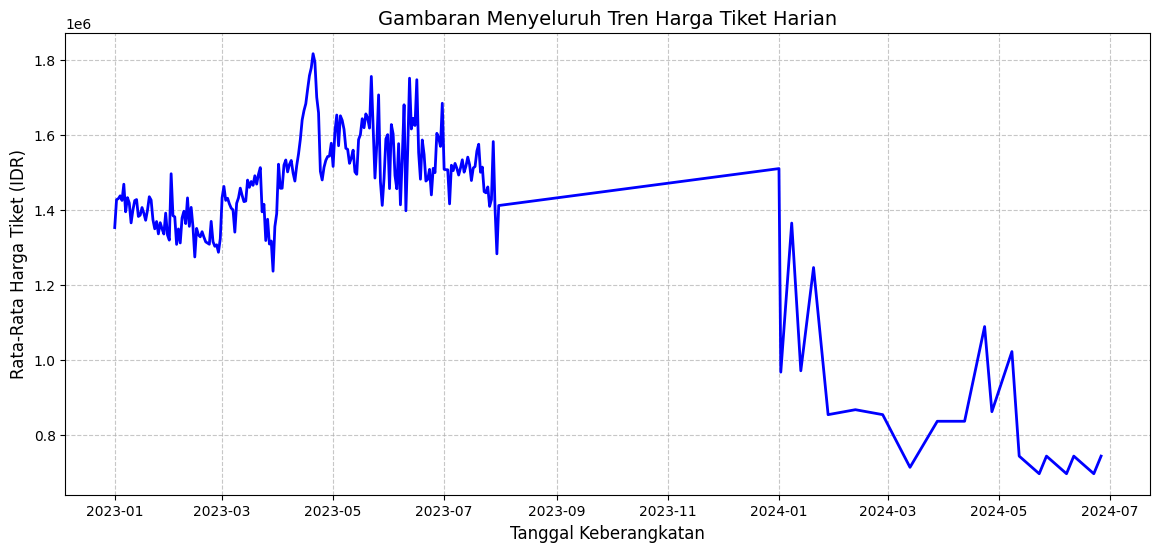

In [ ]:
# Memastikan format tanggal sudah benar
df['depart_date'] = pd.to_datetime(df['depart_date'])

# Mengambil rata-rata harga tiket keseluruhan per harinya
df_trend = df.groupby('depart_date')['best_price'].mean().reset_index()

# Mengurutkan data berdasarkan tanggal dari yang paling lampau
df_trend = df_trend.sort_values('depart_date')

# Visualisasi grafik garis (line chart)
plt.figure(figsize=(14, 6))
plt.plot(df_trend['depart_date'], df_trend['best_price'], color='blue', linewidth=2)

plt.title('Gambaran Menyeluruh Tren Harga Tiket Harian', fontsize=14)
plt.xlabel('Tanggal Keberangkatan', fontsize=12)
plt.ylabel('Rata-Rata Harga Tiket (IDR)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

# Data Preprocessing (Pra Pemrosesan Data)

Sebelum data historis harga tiket dimasukkan ke dalam arsitektur pemodelan LSTM, dataset melalui serangkaian tahap pra-pemrosesan (*data preprocessing*) dengan urutan sebagai berikut:
1. **Data Cleaning**
2. **Data Filtering**
3. **Feature Engineering**
4. **Data Normalization**
5. **Data Transformation**
6. **Data Splitting**

## 4. Data Cleaning (Pembersihan Data)

In [ ]:
print(f"Total baris data mentah awal: {len(df)}")

# A. Data Cleaning (umum untuk seluruh dataset, belum spesifik per rute)
df = df.dropna()
df = df.drop_duplicates()

print(f"Total baris data setelah pembersihan dasar (dropna & drop_duplicates): {len(df)}\n")

Total baris data mentah awal: 45438
Total baris data setelah pembersihan dasar (dropna & drop_duplicates): 45438



## 5. Data Filtering

In [ ]:
df_yia = df[(df['origin'] == 'JKTC') & (df['destination'] == 'YIA')].copy()
df_yia['depart_date'] = pd.to_datetime(df_yia['depart_date'])

print(f"Jumlah baris data mentah untuk rute JKTC-YIA: {len(df_yia)}")

Jumlah baris data mentah untuk rute JKTC-YIA: 1586


### Data Cleaning (Lanjutan)

In [ ]:
# Penanganan Outlier Harga KHUSUS untuk rute JKTC-YIA (Metode IQR)
Q1 = df_yia['best_price'].quantile(0.25)
Q3 = df_yia['best_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_yia = df_yia[(df_yia['best_price'] >= lower_bound) & (df_yia['best_price'] <= upper_bound)]
print(f"Jumlah baris setelah outlier removal khusus rute: {len(df_yia)}\n")

# Mengambil harga minimum harian untuk rute terpilih
df_daily = df_yia.groupby('depart_date')['best_price'].min().reset_index()
df_daily = df_daily.sort_values('depart_date')
df_daily.set_index('depart_date', inplace=True)

print(f"Jumlah tanggal unik yang benar-benar tercatat di data mentah: {len(df_daily)}")

full_date_range = pd.date_range(start=df_daily.index.min(), end=df_daily.index.max(), freq='D')
df_daily = df_daily.reindex(full_date_range)
df_daily.index.name = 'depart_date'

jumlah_hari_kosong = df_daily['best_price'].isna().sum()
print(f"Jumlah hari kosong yang diisi lewat interpolasi linear: {jumlah_hari_kosong}")

df_daily['best_price'] = df_daily['best_price'].interpolate(method='linear').ffill().bfill()

Jumlah baris setelah outlier removal khusus rute: 1480

Jumlah tanggal unik yang benar-benar tercatat di data mentah: 224
Jumlah hari kosong yang diisi lewat interpolasi linear: 319


## 6. Feature Engineering

In [ ]:
# Feature Engineering
dow = df_daily.index.dayofweek
df_daily['is_weekend'] = dow.isin([5, 6]).astype(float)

# Encoding siklis hari-dalam-minggu, agar model bisa mengenali pola tiap hari
df_daily['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df_daily['dow_cos'] = np.cos(2 * np.pi * dow / 7)

print(f"Jumlah data harian runtun waktu (Time Series) setelah dibuat kontinu: {len(df_daily)}")

# Menampilkan preview tabel data yang sudah bersih, difilter, dan berformat time-series
display(df_daily)

Jumlah data harian runtun waktu (Time Series) setelah dibuat kontinu: 543


,best_price,is_weekend,dow_sin,dow_cos
depart_date,,,,
2023-01-01,531160.0,1.0,-0.781831,0.623490
2023-01-02,504600.0,0.0,0.000000,1.000000
2023-01-03,504600.0,0.0,0.781831,0.623490
2023-01-04,504600.0,0.0,0.974928,-0.222521
2023-01-05,522480.0,0.0,0.433884,-0.900969
...,...,...,...,...
2024-06-22,367200.0,1.0,-0.974928,-0.222521
2024-06-23,367200.0,1.0,-0.781831,0.623490
2024-06-24,367200.0,0.0,0.000000,1.000000


## 7. Data Normalization

In [ ]:
# Menentukan titik pembagian data SEBELUM proses scaling, agar scaler tidak
# Memantau nilai harga pada periode testing/masa depan (mencegah data leakage)
RAW_TRAIN_SIZE = int(len(df_daily) * 0.8)
print(f"Jumlah hari untuk fitting scaler (data training saja): {RAW_TRAIN_SIZE} dari {len(df_daily)} total hari\n")

# Membuat scaler terpisah khusus untuk harga, di-fit HANYA pada porsi data training
scaler_price = MinMaxScaler(feature_range=(0, 1))
scaler_price.fit(df_daily[['best_price']].values[:RAW_TRAIN_SIZE])

# Men-transform SELURUH data (train & test) memakai scaler yang sudah dikunci dari data training
scaled_price = scaler_price.transform(df_daily[['best_price']].values)

# Mengambil fitur tambahan yang sudah dalam rentang wajar (tidak perlu di-scale ulang)
other_features = df_daily[['is_weekend', 'dow_sin', 'dow_cos']].values

# Menggabungkan seluruh fitur menjadi satu kesatuan matriks data
# Kolom index 0 = Harga Tiket, kolom selanjutnya = is_weekend, dow_sin, dow_cos
scaled_features = np.hstack((scaled_price, other_features))

Jumlah hari untuk fitting scaler (data training saja): 434 dari 543 total hari



## 8. Data Transformation (Transformasi Data)

Data yang telah dinormalisasi kemudian ditransformasikan menjadi kumpulan data berbasis *window* (*sliding window*) agar sesuai dengan format input yang dibutuhkan oleh model LSTM.

In [ ]:
# Eksperimen Window Size: Diperluas menjadi 14 hari untuk menangkap tren 2 mingguan
WINDOW_SIZE = 14

def create_multivariate_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        # X mengambil semua kolom fitur (Harga & Weekend) selama rentang window
        X.append(data[i:(i + window_size), :])
        # y hanya mengambil kolom target yaitu Harga Tiket (Index 0) pada hari berikutnya
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

X, y = create_multivariate_sequences(scaled_features, WINDOW_SIZE)

## 9. Data Splitting (Pembagian Data)

Tahap terakhir dari pra-pemrosesan adalah membagi dataset menjadi data latih (*training*) dan data uji (*testing*).

In [ ]:
# Titik potong train/test disesuaikan dengan RAW_TRAIN_SIZE yang dipakai saat
# fitting scaler (Bagian 5), agar tidak ada tumpang tindih antara data yang
train_size = RAW_TRAIN_SIZE - WINDOW_SIZE
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Struktur Dimensi Data Train X: {X_train.shape} -> (Samples, Window Size, Features)")
print(f"Struktur Dimensi Data Test X : {X_test.shape}\n")

Struktur Dimensi Data Train X: (420, 14, 4) -> (Samples, Window Size, Features)
Struktur Dimensi Data Test X : (109, 14, 4)



# 10. Visualisasi Data Setelah Pra-Pemrosesan (Rute JKTC-YIA)

Sebelum masuk ke tahap pemodelan, data hasil pra-pemrosesan divisualisasikan untuk memastikan pola data historis (termasuk pembagian data latih/uji) dan pengaruh fitur `is_weekend` yang telah direkayasa sudah sesuai harapan.

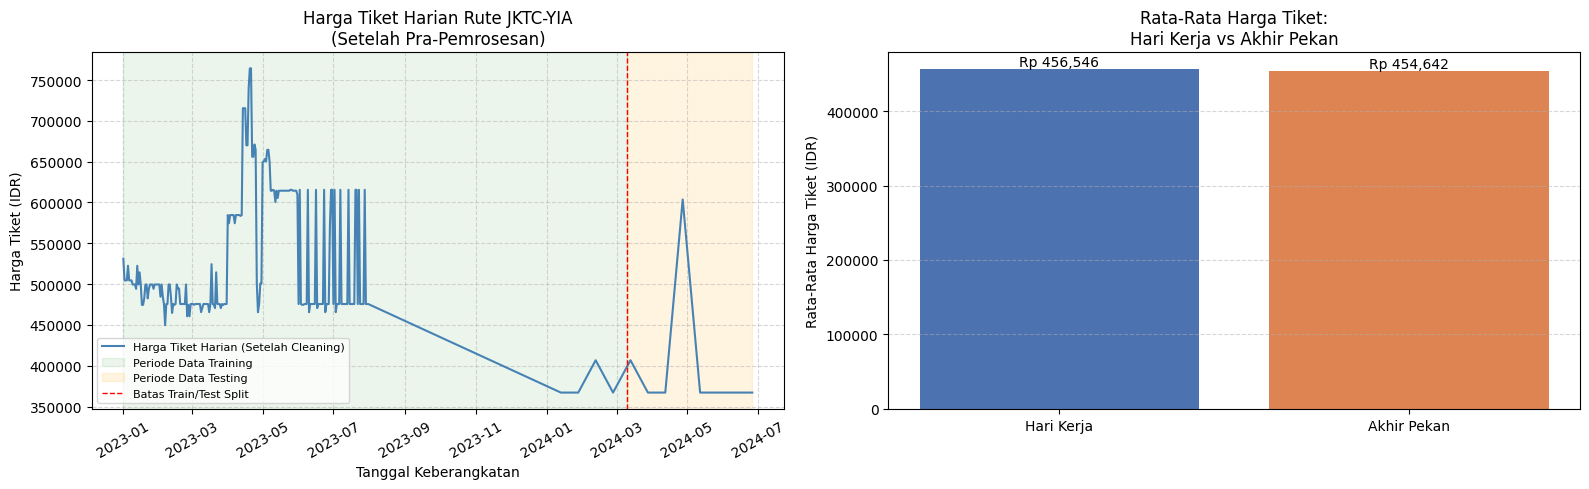

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel kiri: Tren harga tiket harian setelah cleaning & filtering, lengkap dengan area train/test
axes[0].plot(df_daily.index, df_daily['best_price'], color='steelblue', linewidth=1.5,
             label='Harga Tiket Harian (Setelah Cleaning)')

split_date = df_daily.index[train_size + WINDOW_SIZE]
axes[0].axvspan(df_daily.index[0], split_date, color='green', alpha=0.08, label='Periode Data Training')
axes[0].axvspan(split_date, df_daily.index[-1], color='orange', alpha=0.12, label='Periode Data Testing')
axes[0].axvline(split_date, color='red', linestyle='--', linewidth=1, label='Batas Train/Test Split')

axes[0].set_title('Harga Tiket Harian Rute JKTC-YIA\n(Setelah Pra-Pemrosesan)', fontsize=12)
axes[0].set_xlabel('Tanggal Keberangkatan')
axes[0].set_ylabel('Harga Tiket (IDR)')
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=30)

# Panel kanan: Pengaruh fitur is_weekend terhadap rata-rata harga tiket
avg_price_by_day = df_daily.groupby('is_weekend')['best_price'].mean()
labels = ['Hari Kerja', 'Akhir Pekan']
colors = ['#4C72B0', '#DD8452']
bars = axes[1].bar(labels, avg_price_by_day.values, color=colors)
for bar, v in zip(bars, avg_price_by_day.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v, f'Rp {v:,.0f}',
                 ha='center', va='bottom', fontsize=10)

axes[1].set_title('Rata-Rata Harga Tiket:\nHari Kerja vs Akhir Pekan', fontsize=12)
axes[1].set_ylabel('Rata-Rata Harga Tiket (IDR)')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 11. Membangun dan Melatih Model LSTM

In [ ]:
# menentukan dimensi input (persiapan data)
num_features = X_train.shape[2]

# membangun arsitektur model LSTM
model = Sequential([
    Input(shape=(WINDOW_SIZE, num_features)),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

# Model dioptimasi menggunakan Adaptive Moment Estimation (Adam)
# Model diuji loss function menggunakan MSE
model.compile(optimizer='adam', loss='mean_squared_error')

# Mengonfigurasi Early Stopping untuk mencegah overfitting
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

print("Memulai proses training model Multivariate LSTM...")
history = model.fit(
    X_train, y_train,
    epochs=75,
    batch_size=8,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1
)
print("Proses training selesai\n")

Memulai proses training model Multivariate LSTM...
Epoch 1/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0172 - val_loss: 0.0145
Epoch 2/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0117 - val_loss: 0.0135
Epoch 3/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0113 - val_loss: 0.0142
Epoch 4/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0115 - val_loss: 0.0132
Epoch 5/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0104 - val_loss: 0.0128
Epoch 6/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0099 - val_loss: 0.0123
Epoch 7/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0099 - val_loss: 0.0121
Epoch 8/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0101 - val_loss: 0.0110
Epoch 9/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 - val_loss: 0.0102
Epoch 10/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0093 - val_loss: 0.0094
Epoch 11/75
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0095 - val_loss: 0.0088
Epoch 12/75
53/53 ━━━

## Menyimpan Model Hasil Training

Agar hasil prediksi **tidak berubah-ubah** setiap notebook dijalankan ulang, model yang sudah dilatih disimpan ke file.

In [ ]:
# Menyimpan model yang sudah dilatih ke dalam file
model.save('model_lstm_tiket.keras')
print("Model berhasil disimpan sebagai 'model_lstm_tiket.keras'")

Model berhasil disimpan sebagai 'model_lstm_tiket.keras'


# 12. Visualisasi Proses Training (Loss Curve)

Kurva *loss* training vs validasi digunakan untuk memeriksa apakah model mengalami *underfitting* atau *overfitting* selama proses pelatihan.

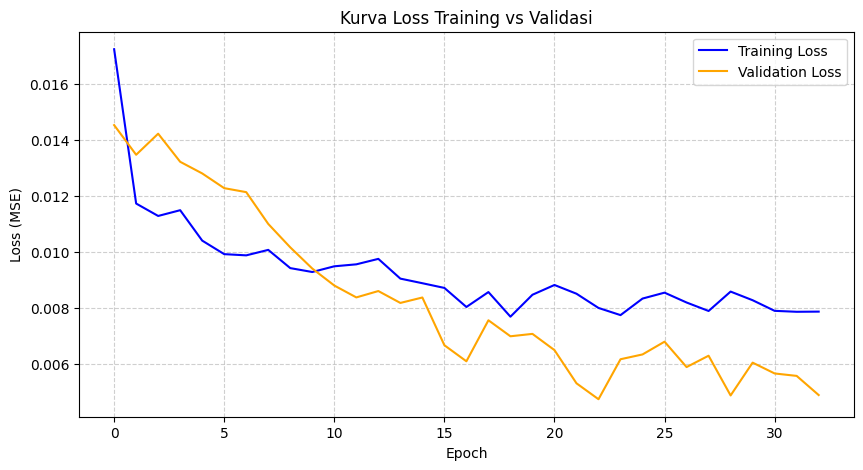

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Kurva Loss Training vs Validasi')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 13. Evaluasi Model LSTM

In [ ]:
# Melakukan prediksi pada data test
predictions_scaled = model.predict(X_test)

# Mengembalikan nilai prediksi dan target aktual ke nominal Rupiah asli
predictions = scaler_price.inverse_transform(predictions_scaled)
y_test_actual = scaler_price.inverse_transform(y_test.reshape(-1, 1))

# Menghitung Metrik Evaluasi Akhir (Nominal)
mae = mean_absolute_error(y_test_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))

# Menghitung persentase melesetnya hasil evaluasi terhadap rata-rata harga aktual
rata_rata_harga_aktual = np.mean(y_test_actual)
mae_percentage = (mae / rata_rata_harga_aktual) * 100
rmse_percentage = (rmse / rata_rata_harga_aktual) * 100

print(f"\n=========================================================")
print(f"HASIL EVALUASI MODEL SETELAH OPTIMASI:")
print(f"Mean Absolute Error (MAE)     : Rp {mae:,.2f}  ({mae_percentage:.2f}% dari rata-rata harga)")
print(f"---------------------------------------------------------")
print(f"Root Mean Squared Error (RMSE): Rp {rmse:,.2f}  ({rmse_percentage:.2f}% dari rata-rata harga)")
print(f"=========================================================\n")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step

HASIL EVALUASI MODEL SETELAH OPTIMASI:
Mean Absolute Error (MAE)     : Rp 19,677.69  (4.88% dari rata-rata harga)
---------------------------------------------------------
Root Mean Squared Error (RMSE): Rp 27,349.39  (6.78% dari rata-rata harga)



# 14. Visualisasi Hasil Prediksi

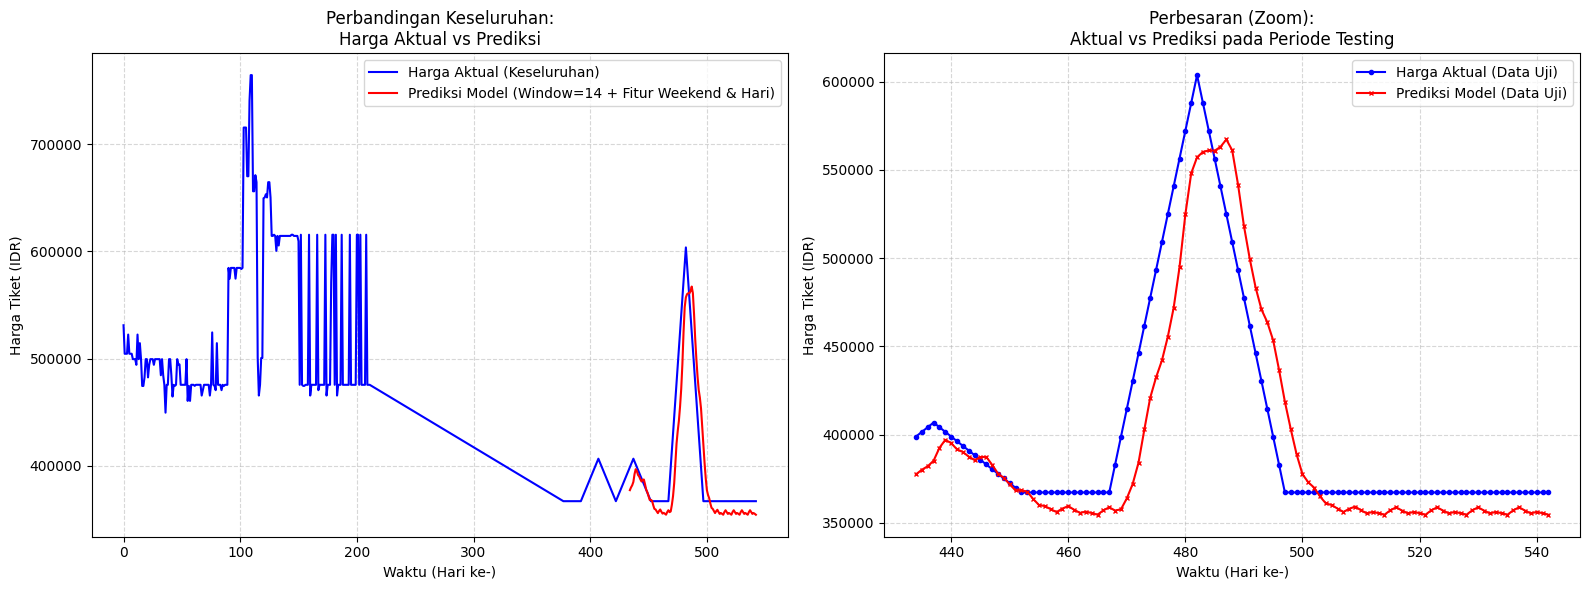

In [ ]:
# Penyiapan data untuk grafik tampilan keseluruhan (runtun waktu berkesinambungan)
data_aktual_keseluruhan = scaler_price.inverse_transform(scaled_features[:, 0].reshape(-1, 1))

grafik_prediksi = np.empty_like(data_aktual_keseluruhan)
grafik_prediksi[:, :] = np.nan
# Menempatkan hasil tebakan tepat di area ujung waktu (sesuai posisi data test)
grafik_prediksi[train_size + WINDOW_SIZE:len(scaled_features), :] = predictions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel kiri: perbandingan keseluruhan runtun waktu
axes[0].plot(data_aktual_keseluruhan, label='Harga Aktual (Keseluruhan)', color='blue')
axes[0].plot(grafik_prediksi, label=f'Prediksi Model (Window={WINDOW_SIZE} + Fitur Weekend & Hari)', color='red')
axes[0].set_title('Perbandingan Keseluruhan:\nHarga Aktual vs Prediksi')
axes[0].set_xlabel('Waktu (Hari ke-)')
axes[0].set_ylabel('Harga Tiket (IDR)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel kanan: perbesaran (zoom) khusus periode data uji, karena porsinya kecil di grafik keseluruhan
test_start = train_size + WINDOW_SIZE
test_range = range(test_start, test_start + len(y_test_actual))
axes[1].plot(test_range, y_test_actual, label='Harga Aktual (Data Uji)', color='blue', marker='o', markersize=3)
axes[1].plot(test_range, predictions, label='Prediksi Model (Data Uji)', color='red', marker='x', markersize=3)
axes[1].set_title('Perbesaran (Zoom):\nAktual vs Prediksi pada Periode Testing')
axes[1].set_xlabel('Waktu (Hari ke-)')
axes[1].set_ylabel('Harga Tiket (IDR)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 15. Contoh Prediksi Harga Tiket untuk Hari Berikutnya

In [ ]:
# Mengambil runtutan window terakhir dari data riil untuk membaca masa depan
last_window = scaled_features[-WINDOW_SIZE:]
last_window = last_window.reshape(1, WINDOW_SIZE, num_features)

next_price_scaled = model.predict(last_window)
next_price = scaler_price.inverse_transform(next_price_scaled)

# Menentukan tanggal yang diprediksi (1 hari setelah data historis terakhir)
next_date = df_daily.index[-1] + pd.Timedelta(days=1)

print(f"Tanggal Prediksi                             : {next_date.strftime('%Y-%m-%d')}")
print(f"Estimasi Harga Tiket untuk 1 Hari Berikutnya : Rp {next_price[0][0]:,.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Tanggal Prediksi                             : 2024-06-27
Estimasi Harga Tiket untuk 1 Hari Berikutnya : Rp 357,069.81
